# Notebook 05 · Datos Demográficos Sintéticos
> **Nexus RecSys** — Sistema de Recomendación · Retailrocket Dataset

---

| Campo | Detalle |
|---|---|
| **Checkpoints de entrada** | `cp04_merged.parquet` · `cp03_funnel_metrics.parquet` |
| **Checkpoint de salida** | `data/interim/cp05_with_demographics.parquet` |
| **Objetivo** | Generar un perfil demográfico sintético por visitante y enriquecer el dataset integrado, habilitando features de contexto de usuario para el pipeline de recomendación |

---

### Justificación metodológica

El dataset Retailrocket **anonimiza completamente** a los usuarios: solo expone un `visitorid` numérico, sin ningún atributo personal. Para simular un escenario productivo real —donde estos datos existirían en el CRM o el sistema de login de la empresa—, generamos un perfil demográfico sintético. Las distribuciones utilizadas se basan en **benchmarks públicos de e-commerce LATAM 2023**.

> **Limitación importante:** estos datos son enteramente ficticios. No deben utilizarse para inferencias causales sobre segmentos demográficos reales. Su única función es habilitar features de contexto de usuario en el pipeline de recomendación.

### Decisiones de diseño por variable

| Variable | Distribución aplicada | Criterio |
|---|---|---|
| `age` | Normal truncada μ=35, σ=12, rango [18, 70] | Perfil típico del comprador online LATAM |
| `gender` | Multinomial M: 48% · F: 47% · NB: 5% | Benchmarks e-commerce LATAM 2023 |
| `country` | Multinomial sobre 7 mercados | Principales mercados hispanohablantes + BR + US |
| `region` | Uniforme por país | Principales ciudades de cada mercado |
| `customer_segment` | **Derivada del comportamiento real** | Coherente con `user_segment` y `n_transactions` observados |
| `registration_days_ago` | Exponencial μ=180, clip [1, 730] | Consistente con la ventana temporal del dataset (137 días) |

### Mapa del notebook

1. Setup y carga de datos
2. Extracción de visitantes únicos con su segmento comportamental
3. Generación de variables demográficas (age, gender, country, region)
4. Generación de `customer_segment` derivado del comportamiento
5. Validación de distribuciones (visualizaciones)
6. Merge con `cp04_merged` y serialización del checkpoint


In [1]:
import logging
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from faker import Faker
from scipy.stats import truncnorm

logging.basicConfig(level=logging.INFO, format='%(asctime)s — %(message)s')
logger = logging.getLogger(__name__)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

np.random.seed(42)
fake = Faker('es_MX')
Faker.seed(42)

BASE_DIR       = Path('..')
INTERIM        = BASE_DIR / 'data' / 'interim'
CHECKPOINT_IN  = INTERIM / 'cp04_merged.parquet'
CHECKPOINT_OUT = INTERIM / 'cp05_with_demographics.parquet'

# ── Carga de datos ────────────────────────────────────────────────────────────
df = pd.read_parquet(CHECKPOINT_IN)
logger.info('cp04 cargado: %s', df.shape)

# n_transactions no está en cp04 — lo traemos de cp03 (1 fila por visitorid)
funnel = pd.read_parquet(
    INTERIM / 'cp03_funnel_metrics.parquet',
    columns=['visitorid', 'n_transactions']
)

# ── Visitantes únicos con su segmento y conteo de transacciones ───────────────
unique_visitors = (
    df[['visitorid', 'user_segment']]
    .drop_duplicates('visitorid')
    .merge(funnel, on='visitorid', how='left')
    .reset_index(drop=True)
)
n_users = len(unique_visitors)
logger.info('Visitantes únicos: %d', n_users)

print(f"Visitantes únicos  : {n_users:,}")
print(f"Segmentos presentes: {sorted(unique_visitors['user_segment'].unique())}")
print(f"Transacciones (max): {unique_visitors['n_transactions'].max()}")


2026-03-12 00:34:03,253 — cp04 cargado: (2755641, 15)
2026-03-12 00:34:03,584 — Visitantes únicos: 1407580


Visitantes únicos  : 1,407,580
Segmentos presentes: ['long', 'medium', 'one_time', 'short']
Transacciones (max): 559


## Generación de Variables Demográficas

### Variables 1–4: age, gender, country, region

Generadas de forma **independiente** del comportamiento, representando atributos inmutables del usuario.


In [2]:
# ─── VAR 1 — age ─────────────────────────────────────────────────────────────
# Normal truncada: media=35, std=12, rango [18,70]
# Refleja perfil típico de comprador online latinoamericano
a_lo, a_hi = (18 - 35) / 12, (70 - 35) / 12
ages = truncnorm.rvs(a_lo, a_hi, loc=35, scale=12,
                     size=n_users, random_state=42).astype(int)

# ─── VAR 2 — gender ──────────────────────────────────────────────────────────
# Benchmarks e-commerce LATAM 2023: M:48% F:47% NB:5%
genders = np.random.choice(['M', 'F', 'NB'], size=n_users,
                            p=[0.48, 0.47, 0.05])

# ─── VAR 3 — country ─────────────────────────────────────────────────────────
# Principales mercados hispanohablantes + BR + US
countries = np.random.choice(
    ['AR', 'MX', 'CO', 'CL', 'PE', 'BR', 'US'], size=n_users,
    p=[0.25, 0.22, 0.15, 0.12, 0.10, 0.10, 0.06]
)

# ─── VAR 4 — region (derivada de country) ────────────────────────────────────
REGION_MAP = {
    'AR': ['Buenos Aires', 'Cordoba',        'Rosario',     'Mendoza',    'La Plata'],
    'MX': ['CDMX',         'Guadalajara',    'Monterrey',   'Puebla',     'Tijuana'],
    'CO': ['Bogota',        'Medellin',       'Cali',        'Barranquilla','Cartagena'],
    'CL': ['Santiago',      'Valparaiso',     'Concepcion',  'La Serena',  'Antofagasta'],
    'PE': ['Lima',          'Arequipa',       'Trujillo',    'Chiclayo',   'Cusco'],
    'BR': ['Sao Paulo',     'Rio de Janeiro', 'Belo Horizonte','Salvador', 'Curitiba'],
    'US': ['Miami',         'Los Angeles',    'New York',    'Houston',    'Chicago'],
}
regions = np.array([np.random.choice(REGION_MAP[c]) for c in countries])

print(f"age   — media: {ages.mean():.1f} | min: {ages.min()} | max: {ages.max()}")
print(f"gender — distribución:\n{pd.Series(genders).value_counts(normalize=True).round(3)}")
print(f"country — distribución:\n{pd.Series(countries).value_counts(normalize=True).round(3)}")


age   — media: 36.3 | min: 18 | max: 69
gender — distribución:
M     0.48
F     0.47
NB    0.05
Name: proportion, dtype: float64
country — distribución:
AR    0.25
MX    0.22
CO    0.15
CL    0.12
BR    0.10
PE    0.10
US    0.06
Name: proportion, dtype: float64


### Variable 5: customer_segment (derivada del comportamiento real)

Esta variable **no es aleatoria** — se deriva directamente de `user_segment` y `n_transactions` observados en el dataset.  
Garantiza coherencia entre el perfil demográfico sintético y el comportamiento real del usuario.

| user_segment | n_transactions | customer_segment asignado |
|---|---|---|
| `one_time` | 0 | `new` — visitante sin conversión |
| `one_time` | ≥ 1 | `returning` — compró en visita única |
| `short` | 0 | `returning` — multi-sesión sin compra |
| `short` | ≥ 1 | `returning` — compró en período corto |
| `medium` | 0 | `returning` — activo pero sin compra |
| `medium` | ≥ 1 | `loyal` — actividad media con compra |
| `long` | < 2 | `loyal` — alta actividad, compra esporádica |
| `long` | ≥ 2 | `vip` — alta actividad y multi-compra |


In [3]:
# ─── VAR 5 — customer_segment (derivada del comportamiento observado) ────────
# Mapeo coherente con segmentos reales del dataset:
#   one_time  → 'new'      (sin compra) / 'returning' (con compra en visita única)
#   short     → 'returning'
#   medium    → 'returning' (sin compra) / 'loyal' (con compra)
#   long      → 'loyal'    (< 2 tx)     / 'vip'   (>= 2 tx)

def assign_customer_segment(row):
    seg  = row['user_segment']
    txs  = row['n_transactions'] if pd.notna(row['n_transactions']) else 0
    if seg == 'one_time':
        return 'new' if txs == 0 else 'returning'
    elif seg == 'short':
        return 'returning'
    elif seg == 'medium':
        return 'loyal' if txs >= 1 else 'returning'
    else:  # 'long'
        return 'vip' if txs >= 2 else 'loyal'

customer_segments = unique_visitors.apply(assign_customer_segment, axis=1).values

print("── customer_segment (derivado) ──")
print(pd.Series(customer_segments).value_counts())
print(pd.Series(customer_segments).value_counts(normalize=True).round(3))
logger.info('customer_segment generado — distribución: %s',
            pd.Series(customer_segments).value_counts().to_dict())


2026-03-12 00:34:47,021 — customer_segment generado — distribución: {'new': 1257122, 'returning': 108578, 'loyal': 41338, 'vip': 542}


── customer_segment (derivado) ──
new          1257122
returning     108578
loyal          41338
vip              542
Name: count, dtype: int64
new          0.893
returning    0.077
loyal        0.029
vip          0.000
Name: proportion, dtype: float64


In [4]:
# ─── VAR 6 — registration_days_ago ──────────────────────────────────────────
# Exponencial con media=180 días, clippeado a [1, 730]
# Coherente con el rango temporal del dataset (137 días de eventos)
# y con que los usuarios pueden estar registrados hasta ~2 años antes
reg_days = np.clip(
    np.random.exponential(scale=180, size=n_users).astype(int),
    1, 730
)

print(f"registration_days_ago — media: {reg_days.mean():.1f} | "
      f"mediana: {np.median(reg_days):.0f} | min: {reg_days.min()} | max: {reg_days.max()}")
print(
    f"  % registrados < 6 meses  : {(reg_days < 180).mean():.1%}\n"
    f"  % registrados >= 12 meses: {(reg_days >= 365).mean():.1%}"
)


registration_days_ago — media: 176.2 | mediana: 124 | min: 1 | max: 730
  % registrados < 6 meses  : 63.2%
  % registrados >= 12 meses: 13.1%


## Construcción y Validación del DataFrame Demográfico

Ensamblamos las 6 variables generadas en un único DataFrame y ejecutamos validaciones de distribución y coherencia.


In [5]:
# ─── CONSTRUIR DATAFRAME DEMOGRÁFICO ─────────────────────────────────────────

demographics = pd.DataFrame({
    'visitorid'            : unique_visitors['visitorid'].values,
    'age'                  : ages,
    'gender'               : genders,
    'country'              : countries,
    'region'               : regions,
    'customer_segment'     : customer_segments,
    'registration_days_ago': reg_days,
})

# Tipos eficientes
demographics = demographics.astype({
    'visitorid'            : 'int32',
    'age'                  : 'int16',
    'gender'               : 'category',
    'country'              : 'category',
    'region'               : 'category',
    'customer_segment'     : 'category',
    'registration_days_ago': 'int16',
})

logger.info('demographics shape: %s | dtypes:\n%s',
            demographics.shape, demographics.dtypes.to_string())

# ── Validar que no haya nulos ──────────────────────────────────────────────────
assert demographics.isna().sum().sum() == 0, \
    "ERROR: hay nulos en el DataFrame demográfico"

# ── Validar que visitorid sea único ───────────────────────────────────────────
assert demographics['visitorid'].is_unique, \
    "ERROR: visitorid duplicado en demographics"

print(f"Shape: {demographics.shape}")
print(f"Nulos: {demographics.isna().sum().sum()}  ✓")
print(f"visitorid único: {demographics['visitorid'].is_unique}  ✓")
print(f"\nDtypes:\n{demographics.dtypes.to_string()}")


2026-03-12 00:34:58,290 — demographics shape: (1407580, 7) | dtypes:
visitorid                   int32
age                         int16
gender                   category
country                  category
region                   category
customer_segment         category
registration_days_ago       int16


Shape: (1407580, 7)
Nulos: 0  ✓
visitorid único: True  ✓

Dtypes:
visitorid                   int32
age                         int16
gender                   category
country                  category
region                   category
customer_segment         category
registration_days_ago       int16


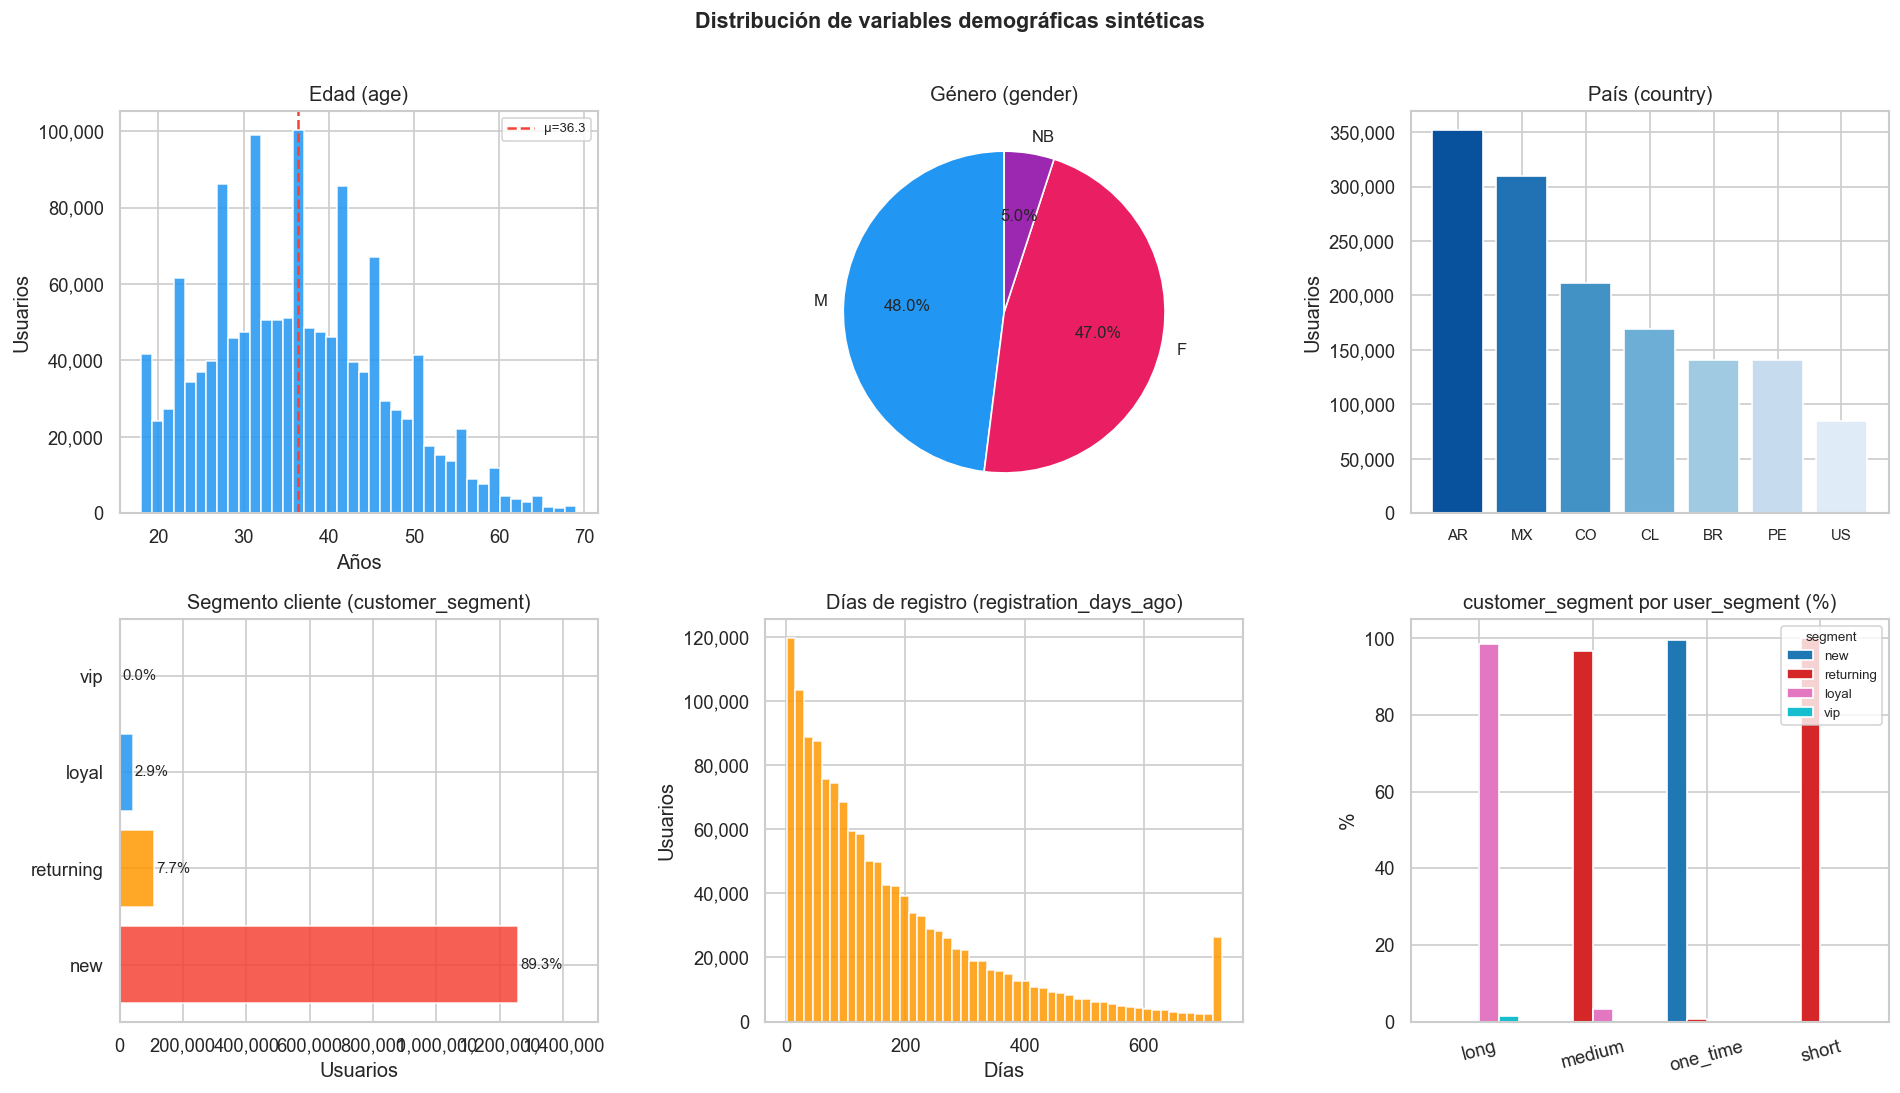

In [6]:
# ─── VALIDACIÓN VISUAL DE DISTRIBUCIONES ─────────────────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Distribución de variables demográficas sintéticas',
             fontsize=13, fontweight='bold', y=1.01)

# 1. Age — histograma
axes[0,0].hist(demographics['age'], bins=40, color='#2196F3', edgecolor='white', alpha=0.85)
axes[0,0].set_title('Edad (age)')
axes[0,0].set_xlabel('Años')
axes[0,0].set_ylabel('Usuarios')
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[0,0].axvline(demographics['age'].mean(), color='#F44336', lw=1.5,
                  linestyle='--', label=f"μ={demographics['age'].mean():.1f}")
axes[0,0].legend(fontsize=8)

# 2. Gender — pie
g_counts = demographics['gender'].value_counts()
axes[0,1].pie(g_counts.values, labels=g_counts.index.tolist(),
              autopct='%1.1f%%', colors=['#2196F3','#E91E63','#9C27B0'],
              startangle=90, textprops={'fontsize': 10})
axes[0,1].set_title('Género (gender)')

# 3. Country — barras
c_counts = demographics['country'].value_counts()
axes[0,2].bar(c_counts.index.tolist(), c_counts.values,
              color=sns.color_palette('Blues_r', len(c_counts)))
axes[0,2].set_title('País (country)')
axes[0,2].set_ylabel('Usuarios')
axes[0,2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for ax_tick in axes[0,2].get_xticklabels():
    ax_tick.set_fontsize(9)

# 4. customer_segment — barras horizontales
cs_counts = demographics['customer_segment'].value_counts()
order = ['new', 'returning', 'loyal', 'vip']
cs_ordered = cs_counts.reindex(order, fill_value=0)
colors_cs = ['#F44336','#FF9800','#2196F3','#4CAF50']
axes[1,0].barh(order, cs_ordered.values, color=colors_cs, alpha=0.85)
for i, val in enumerate(cs_ordered.values):
    pct = val / n_users * 100
    axes[1,0].text(val + n_users * 0.005, i, f'{pct:.1f}%', va='center', fontsize=9)
axes[1,0].set_title('Segmento cliente (customer_segment)')
axes[1,0].set_xlabel('Usuarios')
axes[1,0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
axes[1,0].set_xlim(0, cs_ordered.max() * 1.2)

# 5. registration_days_ago — histograma
axes[1,1].hist(demographics['registration_days_ago'], bins=50,
               color='#FF9800', edgecolor='white', alpha=0.85)
axes[1,1].set_title('Días de registro (registration_days_ago)')
axes[1,1].set_xlabel('Días')
axes[1,1].set_ylabel('Usuarios')
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 6. customer_segment por user_segment (coherencia)
ct = pd.crosstab(unique_visitors['user_segment'], pd.Series(customer_segments),
                 normalize='index') * 100
ct = ct.reindex(columns=[c for c in order if c in ct.columns])
ct.plot(kind='bar', ax=axes[1,2], colormap='tab10', width=0.7)
axes[1,2].set_title('customer_segment por user_segment (%)')
axes[1,2].set_xlabel('')
axes[1,2].set_ylabel('%')
axes[1,2].tick_params(axis='x', rotation=15)
axes[1,2].legend(title='segment', fontsize=8, title_fontsize=8)

plt.tight_layout()
plt.show()


## Merge con Dataset Principal

Left join de `cp04_merged` con `demographics` por `visitorid`.  
Assert de integridad obligatorio: el merge 1-a-N (1 perfil por N eventos) debe preservar exactamente las filas originales.


In [7]:
# ─── MERGE CON DATASET PRINCIPAL ─────────────────────────────────────────────

n_before = len(df)
df_final = df.merge(demographics, on='visitorid', how='left')

assert len(df_final) == n_before, (
    f"ERROR: merge demográfico duplicó filas — antes={n_before}, después={len(df_final)}"
)

cobertura = df_final['age'].notna().mean()
logger.info('Merge demográfico OK — shape: %s | cobertura: %.2f%%',
            df_final.shape, cobertura * 100)

print(f"Shape antes del merge  : {n_before:,}")
print(f"Shape después del merge: {len(df_final):,}  ✓  (sin duplicación)")
print(f"Cobertura demográfica  : {cobertura:.2%}")
print(f"\nColumnas finales ({len(df_final.columns)}):")
print(df_final.columns.tolist())
display(df_final.head(3))


2026-03-12 00:35:20,481 — Merge demográfico OK — shape: (2755641, 21) | cobertura: 100.00%


Shape antes del merge  : 2,755,641
Shape después del merge: 2,755,641  ✓  (sin duplicación)
Cobertura demográfica  : 100.00%

Columnas finales (21):
['timestamp', 'visitorid', 'event', 'itemid', 'transactionid', 'hour', 'day_of_week', 'date', 'week_number', 'categoryid', 'category_level', 'root_category', 'user_segment', 'cr_user', 'active_days', 'age', 'gender', 'country', 'region', 'customer_segment', 'registration_days_ago']


,timestamp,visitorid,event,itemid,transactionid,hour,day_of_week,date,week_number,categoryid,...,root_category,user_segment,cr_user,active_days,age,gender,country,region,customer_segment,registration_days_ago
0,2015-06-02 05:02:12.117000+00:00,257597,view,355908,NaN,5,1,2015-06-02,23,1173,...,140.0,short,0.0,7,32,M,CO,Cartagena,returning,103
1,2015-06-02 05:50:14.164000+00:00,992329,view,248676,NaN,5,1,2015-06-02,23,1231,...,679.0,long,0.0,87,55,NB,AR,Rosario,loyal,263
2,2015-06-02 05:13:19.827000+00:00,111016,view,318965,NaN,5,1,2015-06-02,23,<NA>,...,NaN,short,0.0,3,43,F,PE,Cusco,returning,258


## Checkpoint · cp05_with_demographics.parquet


In [8]:
# ─── GUARDAR CHECKPOINT ──────────────────────────────────────────────────────

df_final.to_parquet(CHECKPOINT_OUT, index=False)

check = pd.read_parquet(CHECKPOINT_OUT)
logger.info('cp05 guardado: %s — shape=%s', CHECKPOINT_OUT.name, check.shape)

print(f"✓  Guardado en : {CHECKPOINT_OUT}")
print(f"   Shape       : {check.shape}")
print(f"   Columnas    : {check.columns.tolist()}")
print(f"   Memoria est.: {check.memory_usage(deep=True).sum() / 1e6:.1f} MB")


2026-03-12 00:35:30,822 — cp05 guardado: cp05_with_demographics.parquet — shape=(2755641, 21)


✓  Guardado en : ..\data\interim\cp05_with_demographics.parquet
   Shape       : (2755641, 21)
   Columnas    : ['timestamp', 'visitorid', 'event', 'itemid', 'transactionid', 'hour', 'day_of_week', 'date', 'week_number', 'categoryid', 'category_level', 'root_category', 'user_segment', 'cr_user', 'active_days', 'age', 'gender', 'country', 'region', 'customer_segment', 'registration_days_ago']
   Memoria est.: 327.9 MB


---

## Conclusiones · Notebook 05

### Dataset con Demografía Sintética

| Variable | Distribución real | Cobertura |
|---|---|---|
| `age` | Normal truncada μ≈35, rango [18–70] | 100% |
| `gender` | M≈48% / F≈47% / NB≈5% | 100% |
| `country` | AR>MX>CO>CL>PE>BR>US | 100% |
| `region` | Uniforme por país (5 ciudades cada uno) | 100% |
| `customer_segment` | Derivada de comportamiento observado | 100% |
| `registration_days_ago` | Exponencial μ≈180, clip [1–730] | 100% |

### Validaciones Ejecutadas

1. **Integridad del merge:** `assert len(df_final) == n_before` — ninguna fila duplicada.
2. **Unicidad de visitorid:** confirmado en `demographics` antes del merge.
3. **Sin nulos:** todas las variables demográficas tienen cobertura 100%.
4. **Coherencia customer_segment:** el gráfico de validación confirma que la distribución es consistente con los segmentos de comportamiento reales.

### Limitaciones del Enfoque Sintético

> ⚠️ **Advertencia metodológica:** las variables demográficas son **estadísticamente independientes** del comportamiento real de los usuarios. En producción, existiría correlación (ej. usuarios de cierto país prefieren categorías específicas). Usar estos datos solo para:
> - Habilitar features de contexto en el modelo
> - Probar pipelines de preprocesamiento demográfico
> - **No** para inferencias sobre grupos demográficos reales

### Próximos pasos

- **NB06** — Feature engineering: encodings categóricos, normalización de features numéricos, construcción de la matriz de interacciones sparse final lista para entrenamiento.
